# 🧑‍🎨 Notebook 2: Style Transfer

## 📦 Imports

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os



## ⚙️ Device Config

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"[INFO] Using device: {device}")



[INFO] Using device: mps


## 🖼️ Load Images

In [42]:
content_path = '../outputs/01masked_full.jpg'
style_path = '../styles/ethnic.jpg'
image_size = 512

loader = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

content_img = load_image(content_path)
style_img = load_image(style_path)



## 👁️ Visualize

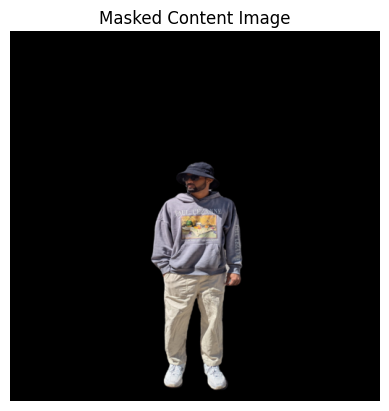

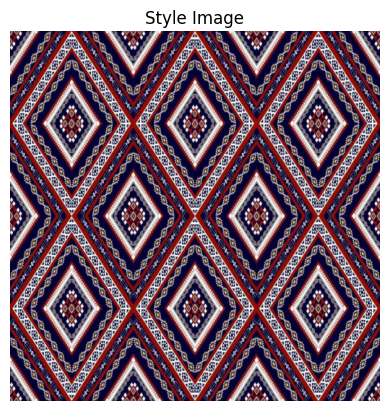

In [43]:
def imshow(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

imshow(content_img, title="Masked Content Image")
imshow(style_img, title="Style Image")



## 🧠 Style Transfer Utilities

In [44]:
def gram_matrix(input_tensor):
    batch_size, channel, height, width = input_tensor.size()
    features = input_tensor.view(channel, height * width)
    G = torch.mm(features, features.t())
    return G.div(channel * height * width)

class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input



## 🧱 Normalization + VGG Model

In [45]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std



## 🧠 Build the Style Transfer Model

In [46]:
def get_model_and_losses(cnn, normalization_mean, normalization_std,
                         style_img, content_img,
                         content_layers=['conv_4'],
                         style_layers=['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']):

    normalization = Normalization(normalization_mean, normalization_std).to(device)
    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        else:
            continue

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # Trim off unused layers
    for j in range(len(model) - 1, -1, -1):
        if isinstance(model[j], (ContentLoss, StyleLoss)):
            break
    model = model[:j+1]

    return model, style_losses, content_losses


In [47]:
input_img = content_img.clone().requires_grad_(True)


🎯 Run the Optimization Loop


In [48]:
model, style_losses, content_losses = get_model_and_losses(
    cnn, cnn_normalization_mean, cnn_normalization_std,
    style_img, content_img
)

optimizer = optim.Adam([input_img], lr=0.01)
num_steps = 300
style_weight = 1e6
content_weight = 1e0

for step in range(1, num_steps + 1):
    def closure():
        optimizer.zero_grad()
        model(input_img)

        style_score = sum(sl.loss for sl in style_losses)
        content_score = sum(cl.loss for cl in content_losses)

        style_loss_val = style_score.item()
        content_loss_val = content_score.item()

        loss = style_score * style_weight + content_score * content_weight
        loss.backward()

        if step % 50 == 0 or step == 1:
            print(f"Step {step} — Style Loss: {style_loss_val:.4f}, Content Loss: {content_loss_val:.4f}")

        return loss

    optimizer.step(closure)


Step 1 — Style Loss: 0.6561, Content Loss: 0.0000
Step 50 — Style Loss: 0.0781, Content Loss: 90.3100
Step 100 — Style Loss: 0.0280, Content Loss: 105.5063
Step 150 — Style Loss: 0.0127, Content Loss: 111.9010
Step 200 — Style Loss: 0.0073, Content Loss: 113.9320
Step 250 — Style Loss: 0.0049, Content Loss: 114.7184
Step 300 — Style Loss: 0.0036, Content Loss: 115.2359


## 🔚 Save the Output Image

In [49]:
output_image = input_img.clone().detach().cpu().squeeze(0)
output_image = transforms.ToPILImage()(output_image.clamp(0, 1))

# Save path
output_path = "../outputs/ethnic_stylized_masked.jpg"
output_image.save(output_path)

print(f"[✅] Stylized image saved at: {output_path}")


[✅] Stylized image saved at: ../outputs/ethnic_stylized_masked.jpg


🖼️ Display Side-by-Side

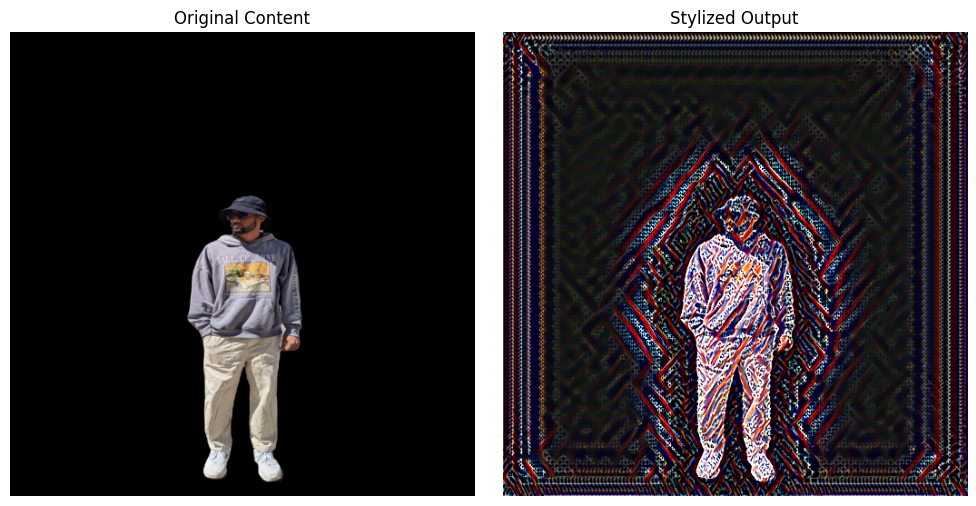

In [50]:
original = transforms.ToPILImage()(content_img.cpu().squeeze(0))
stylized = output_image

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original)
axs[0].set_title("Original Content")
axs[0].axis("off")

axs[1].imshow(stylized)
axs[1].set_title("Stylized Output")
axs[1].axis("off")

plt.tight_layout()
plt.show()


In [51]:
from PIL import Image

# Load images
stylized = Image.open("../outputs/02_stylized_masked.jpg").convert("RGBA")
mask = Image.open("../outputs/01_mask.png").convert("L").resize(stylized.size)
black_bg = Image.new("RGBA", stylized.size, (0, 0, 0, 255))

# Blend stylized image on black background using mask
final = Image.composite(stylized, black_bg, mask)

# Save
final_path = "../outputs/03_final_stylized_blended.png"
final.save(final_path)
print(f"[✅] Final blended stylized image saved to: {final_path}")

# Show result
final.show()


[✅] Final blended stylized image saved to: ../outputs/03_final_stylized_blended.png
